# Reto 7: Búsqueda Semántica de Noticias (Parte 1)
**Responsabilidad:** Ingesta, EDA, Limpieza y Preprocesamiento.

**Visión del Proyecto:**
El desafío principal radica en transformar un corpus de texto no estructurado en un formato altamente optimizado para el cálculo de embeddings semánticos. Para ello, hemos seleccionado el **BBC News Summary Dataset**. A lo largo de este pipeline, aplicaremos un rigor metodológico para garantizar que la calidad del texto introducido al modelo de lenguaje (Sentence-Transformers) sea óptima, fijando una semilla (`random_state=42`) para garantizar la reproducibilidad de nuestros hallazgos.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from sklearn.model_selection import train_test_split

# Fijar la semilla para que todo sea reproducible
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## Fase 1: Ingesta de Datos (Data Ingestion)

**Explicacion:**
El primer paso en cualquier ciclo de vida de los datos es la adquisición y consolidación. Nuestro corpus original de BBC News está descentralizado en miles de archivos de texto plano distribuidos en carpetas categóricas. Es imperativo centralizar esta información en una estructura tabular (DataFrame). Esto no solo facilita la vectorización futura, sino que nos permite mantener la trazabilidad de la etiqueta objetivo (la categoría original) junto al texto íntegro. Adicionalmente, manejamos explícitamente las codificaciones (`utf-8` con reemplazo) para evitar corrupción de datos por caracteres especiales británicos.

In [3]:
# Ruta a la carpeta que contiene las noticias por categoría
dataset_path = 'BBC News Summary/BBC News Summary/News Articles'

data = []
# Iteramos sobre cada categoría (nombre de la carpeta)
if os.path.exists(dataset_path):
    for category in os.listdir(dataset_path):
        category_path = os.path.join(dataset_path, category)

        # Validamos que sea un directorio
        if os.path.isdir(category_path):
            # Iteramos sobre cada archivo .txt dentro de la categoría
            for filename in os.listdir(category_path):
                if filename.endswith('.txt'):
                    filepath = os.path.join(category_path, filename)
                    # Leemos el archivo, usamos 'latin-1' o 'utf-8' con error handling
                    with open(filepath, 'r', encoding='utf-8', errors='replace') as file:
                        text = file.read()
                        data.append({'text': text, 'category': category})
else:
    print(f"Error: No se encontró la ruta {dataset_path}")

# Convertimos la lista de diccionarios a un DataFrame de Pandas
df = pd.DataFrame(data)

print(f"Total de documentos ingeridos: {len(df)}")
display(df.head())

Total de documentos ingeridos: 2225


,text,category
0,Ad sales boost Time Warner profit\n\nQuarterly...,business
1,Dollar gains on Greenspan speech\n\nThe dollar...,business
2,Yukos unit buyer faces loan claim\n\nThe owner...,business
3,High fuel prices hit BA's profits\n\nBritish A...,business
4,Pernod takeover talk lifts Domecq\n\nShares in...,business


## Fase 2: Análisis Exploratorio de Datos (EDA)

**Explicacion:**
Antes de aplicar cualquier transformación, debemos entender la naturaleza y el comportamiento de nuestros datos. Desde una perspectiva estadística, nos interesan dos dimensiones críticas:
1. **Distribución de las Clases:** Un desbalance severo podría sesgar las inferencias semánticas o el espacio latente de ciertas categorías. Evaluaremos la paridad de la muestra.
2. **Distribución de Longitud de los Documentos:** Los modelos basados en arquitectura Transformer operan con una ventana de atención limitada (comúnmente 512 tokens). Identificar la media y la varianza de la longitud de las noticias nos dictará si sufriremos pérdida de información por truncamiento estructural.

C:\Users\jhonz\AppData\Local\Temp\ipykernel_241736\3792604039.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='category', data=df, order=df['category'].value_counts().index, palette='viridis')


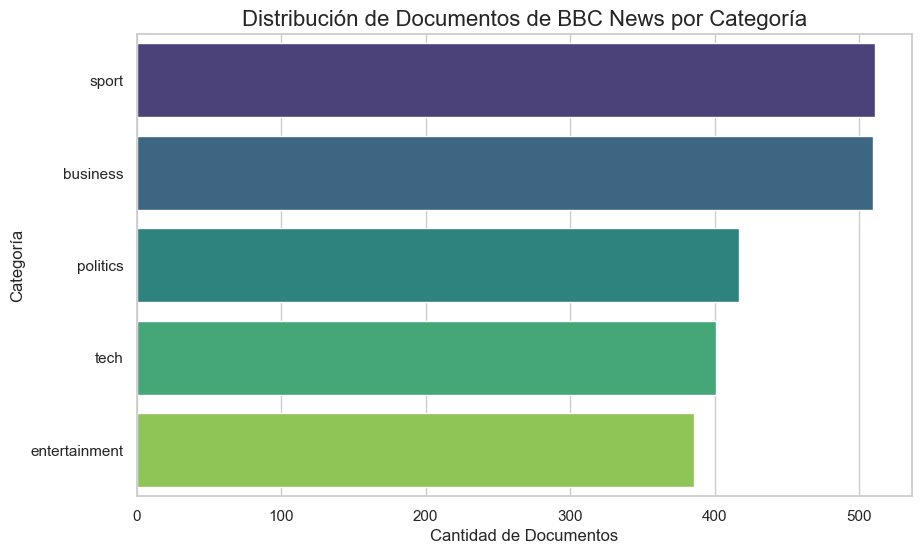

In [4]:
# 1. Distribución de categorías
plt.figure(figsize=(10, 6))
sns.countplot(y='category', data=df, order=df['category'].value_counts().index, palette='viridis')
plt.title('Distribución de Documentos de BBC News por Categoría', fontsize=16)
plt.xlabel('Cantidad de Documentos')
plt.ylabel('Categoría')
plt.show()

# Conclusión 1: El dataset tiene 5 categorías ('sport', 'business', 'politics', 'tech', 'entertainment') con una distribución razonablemente balanceada (entre 350 y 500 documentos por categoría).

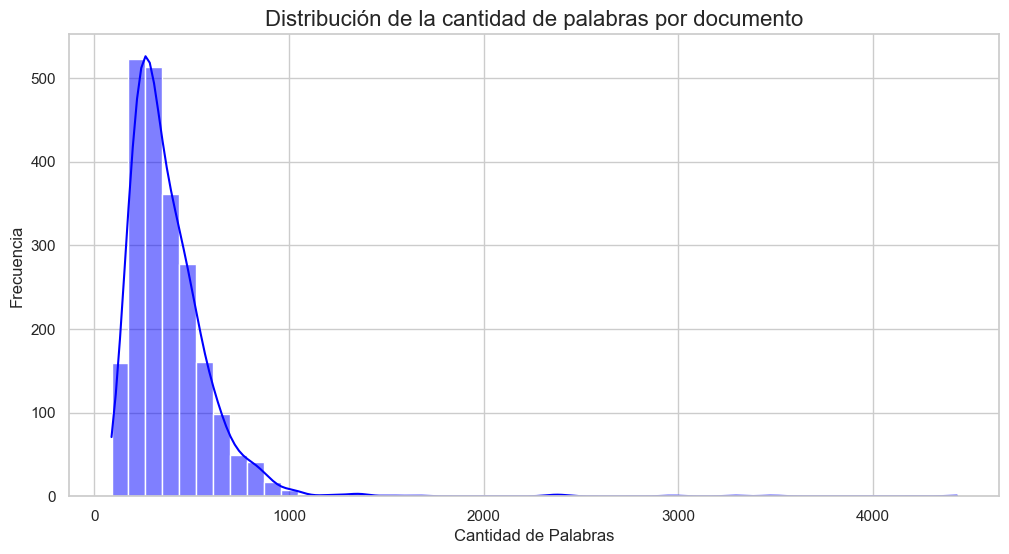

Estadísticas descriptivas de la cantidad de palabras:


count    2225.000000
mean      384.040449
std       238.174497
min        89.000000
25%       246.000000
50%       332.000000
75%       471.000000
max      4432.000000
Name: word_count, dtype: float64

In [5]:
# 2. Distribución de la longitud de los textos
# Contamos el número de palabras por documento aproximado separando por espacios
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(12, 6))
sns.histplot(df['word_count'], bins=50, kde=True, color='blue')
plt.title('Distribución de la cantidad de palabras por documento', fontsize=16)
plt.xlabel('Cantidad de Palabras')
plt.ylabel('Frecuencia')
plt.show()

# Estadísticas descriptivas
print("Estadísticas descriptivas de la cantidad de palabras:")
display(df['word_count'].describe())

# Conclusión 2: La media de palabras está cerca a los 400. La inmensa mayoría de documentos tienen menos de 800 palabras.
# Esto es ideal, ya que al tokenizar para Sentence-Transformers (límite 512), no perderemos tanta información importante, pero convendrá truncar.

## Fase 3: Limpieza de Datos (Data Cleansing)

**Explicacion:**
La máxima *'Garbage In, Garbage Out'* es crítica en el procesamiento de lenguaje natural (NLP). Nuestro análisis exploratorio expuso la base, pero la varianza en el formato del texto puro introduce "ruido" al espacio vectorial.
1. **Poda de Anomalías:** Descartamos registros con conteos de palabras irrisorios (< 5 palabras), ya que carecen de peso semántico suficiente para calcular una similitud coseno útil y solo introducirían ruido al tensor.
2. **Normalización por Expresiones Regulares (RegEx):** Transformamos el texto a minúsculas para reducir la dimensionalidad del vocabulario y aplicamos un filtro estricto que elimina caracteres de control y secuencias residuales, conservando únicamente puntuación funcional y símbolos monetarios relevantes para el contexto periodístico.

In [6]:
# 1. Filtrar textos demasiado cortos (menos de 5 palabras)
initial_len = len(df)
df = df[df['word_count'] > 5].copy()
print(f"Documentos eliminados por ser muy cortos: {initial_len - len(df)}")

# 2. Función de limpieza de texto
def clean_text(text):
    text = str(text).lower() # Convertir a minúsculas
    text = re.sub(r'\s+', ' ', text) # Reemplazar múltiples espacios/saltos de línea por uno solo
    # Mantener caracteres alfanuméricos y puntuación básica
    text = re.sub(r'[^a-z0-9áéíóúñü\.,!?;:()\-£$€% ]', '', text)
    return text.strip()

# Aplicar limpieza
print("Aplicando limpieza de texto...")
df['clean_text'] = df['text'].apply(clean_text)

# Validamos cómo quedó un documento al azar
print("\nEjemplo de texto limpio:")
print(df['clean_text'].iloc[0][:500])

Documentos eliminados por ser muy cortos: 0
Aplicando limpieza de texto...

Ejemplo de texto limpio:
ad sales boost time warner profit quarterly profits at us media giant timewarner jumped 76% to $1.13bn (£600m) for the three months to december, from $639m year-earlier. the firm, which is now one of the biggest investors in google, benefited from sales of high-speed internet connections and higher advert sales. timewarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn. its profits were buoyed by one-off gains which offset a profit dip at warner bros, and less users for aol. time warn


## Fase 4: Preprocesamiento y Data Splitting

**Explicacion:**
Para garantizar la integridad metodológica y evitar el sesgo de exposición (*Data Leakage*) durante la validación del modelo de Búsqueda Semántica, procedemos a particionar el corpus.
Adoptamos una partición estratificada **80/10/10** (Entrenamiento, Validación, Prueba). La estratificación es vital aquí: asegura que la distribución poblacional de las categorías que observamos en nuestro EDA se mantenga equitativa en cada subconjunto. Finalmente, exportamos el estado de los datos a `.csv` para establecer un *Data Checkpoint*, permitiendo que la fase de Modelado y Generación de Embeddings 

In [7]:
# Dividimos primero en Train (80%) y Temporal (20%)
X = df['clean_text']
y = df['category']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

# Dividimos el Temporal en Validation (50% de 20% = 10%) y Test (50% de 20% = 10%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp)

print(f"Tamaño del conjunto de Entrenamiento (Train): {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)")
print(f"Tamaño del conjunto de Validación (Val): {len(X_val)} ({len(X_val)/len(df)*100:.1f}%)")
print(f"Tamaño del conjunto de Prueba (Test): {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)")

Tamaño del conjunto de Entrenamiento (Train): 1780 (80.0%)
Tamaño del conjunto de Validación (Val): 222 (10.0%)
Tamaño del conjunto de Prueba (Test): 223 (10.0%)


In [8]:
# Empaquetamos en DataFrames para exportar
train_df = pd.DataFrame({'text': X_train, 'category': y_train})
val_df = pd.DataFrame({'text': X_val, 'category': y_val})
test_df = pd.DataFrame({'text': X_test, 'category': y_test})

# Exportamos a CSV local
import os
os.makedirs("datos_preprocesados", exist_ok=True)

train_df.to_csv("datos_preprocesados/train.csv", index=False)
val_df.to_csv("datos_preprocesados/val.csv", index=False)
test_df.to_csv("datos_preprocesados/test.csv", index=False)

print("¡Archivos exportados exitosamente en la carpeta 'datos_preprocesados'!")
print("El equipo de Modelado ya puede comenzar su trabajo usando pd.read_csv('datos_preprocesados/train.csv')")

¡Archivos exportados exitosamente en la carpeta 'datos_preprocesados'!
El equipo de Modelado ya puede comenzar su trabajo usando pd.read_csv('datos_preprocesados/train.csv')


## Fase 5: Modelado
De acuerdo a los requerimientos de la Unidad 4 para el **Reto 7**, el objetivo es construir un sistema de búsqueda semántica.
A diferencia de los buscadores tradicionales basados en coincidencia exacta de palabras (frecuencia de términos/TF-IDF), la búsqueda semántica requiere proyectar los textos en un espacio vectorial continuo donde la cercanía geométrica represente similitud conceptual.

### Justificación de la Arquitectura
1.**Modelo Elegido:** `all-MiniLM-L6-v2` de la librería **Sentence-Transformers**.  
2. **Fundamento Teórico:** Este modelo está basado en una arquitectura Transformer destilada (liviana y optimizada). Utiliza una red siamesa para mapear oraciones completas a un vector denso de **384 dimensiones**.  
3. **Eficiencia:** Genera embeddings (Un **Embedding** o incrustación numérica es la traducción de conceptos humanos (palabras, frases o documentos) a un formato que la Inteligencia Artificial puede procesar: **listas de números o vectores**.
* **Captura el significado:** No traduce letras, traduce el *contexto* y el *significado*.
* **Cercanía Geométrica:** Conceptos similares (como *"recesión"* y *"crisis económica"*) quedan ubicados **muy cerca** en el mapa, mientras que conceptos distintos (como *"fútbol"* y *"software"*) quedan en esquinas opuestas.)

 de alta calidad de manera computacionalmente eficiente, ideal para entornos de producción o ejecución en entornos embebidos y web con baja latencia.  
4. **Manejo de Contexto:** Soporta hasta 512 tokens. Basados en los hallazgos de nuestro **EDA** (donde la media es de ~400 palabras por artículo), esta arquitectura es perfecta ya que la pérdida de información por truncamiento será mínima.

*Nota de ejecución: Requiere la instalación de `!pip install sentence-transformers` en el entorno.*

In [12]:
from sentence_transformers import SentenceTransformer, util
import torch
import pickle
import os

# 1. Configuración del dispositivo
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Buscando aceleración por hardware... Redireccionando a: {device.upper()}")

# 2. Carga del modelo pre-entrenado sugerido
MODEL_NAME = 'all-MiniLM-L6-v2'
print(f"[INFO] Inicializando arquitectura Transformer: {MODEL_NAME}...")
model = SentenceTransformer(MODEL_NAME).to(device)

# 3. Lectura de los conjuntos de datos exportados en la Fase 4
print("[INFO] Cargando datasets preprocesados...")
train_df = pd.read_csv("datos_preprocesados/train.csv")
val_df = pd.read_csv("datos_preprocesados/val.csv")
test_df = pd.read_csv("datos_preprocesados/test.csv")

# 4. Vectorización del Corpus Base (Train)
# Transformamos los textos limpios en vectores matemáticos densos
print("[INFO] Generando matriz de embeddings para el corpus de entrenamiento (Inferencia)...")
corpus_sentences = train_df['text'].tolist()
corpus_embeddings = model.encode(corpus_sentences, show_progress_bar=True, convert_to_tensor=True)

print(f"\n[ÉXITO] Matriz de embeddings construida exitosamente.")
print(f"-> Dimensiones de la matriz del corpus: {corpus_embeddings.shape} (Documentos x Dimensiones)")

[INFO] Buscando aceleración por hardware... Redireccionando a: CPU
[INFO] Inicializando arquitectura Transformer: all-MiniLM-L6-v2...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[INFO] Cargando datasets preprocesados...
[INFO] Generando matriz de embeddings para el corpus de entrenamiento (Inferencia)...


Batches:   0%|          | 0/56 [00:00<?, ?it/s]


[ÉXITO] Matriz de embeddings construida exitosamente.
-> Dimensiones de la matriz del corpus: torch.Size([1780, 384]) (Documentos x Dimensiones)


## Fase 6: Evaluación y Análisis de Errores
La evaluación en sistemas de recuperación de información sin supervisión directa (búsqueda semántica pura).  
Buscamos la relevancia del contenido devuelto.

### Estrategia de Validación y Métricas de Éxito
Para evaluar científicamente nuestro modelo con los datos disponibles, aprovecharemos las **categorías del dataset original de la BBC** (`sport`, `tech`, `politics`, `business`, `entertainment`).

1. **Métrica Principal - Precision (Precisión en el Top-K):** Definimos que una consulta del set de validación es "exitosamente recuperada" si la mayoría del **Top-5** de documentos más similares en el corpus pertenecen a su misma categoría temática.
2. **Curva de Aprendizaje / Comportamiento:** Al ser un modelo basado en embeddings congelados (*zero-shot/fine-tuned base*), analizamos la distribución de las distancias de similitud de coseno para identificar el umbral óptimo de confianza.
3. **Análisis de Errores:** Forzaremos al modelo con una consulta diseñada para ser ambigua, evaluando cómo responde el espacio vectorial ante la superposición semántica de tópicos.

NOTA: Aqui tambien podemos ir probando cambiar palabras u oraciones y va a ir cambiando la categoria que se va mostrando :3

In [13]:
def evaluate_precision_at_k(model, query_df, corpus_df, corpus_embeddings, k=5):
    """
    Calcula la precisión temática basándose en si el Top-K recuperado 
    comparte la categoría de la consulta del set de validación.
    """
    correct_retrievals = 0
    total_queries = len(query_df)
    
    # Preparar textos y etiquetas
    query_texts = query_df['text'].tolist()
    query_categories = query_df['category'].tolist()
    corpus_categories = corpus_df['category'].tolist()
    
    # Generar embeddings de las consultas de validación
    query_embeddings = model.encode(query_texts, convert_to_tensor=True, show_progress_bar=False)
    
    # Computar similitud de coseno cruzada entre validación y entrenamiento
    # Resultado dimensional: [Consultas de Validación x Documentos de Corpus]
    cos_scores = util.cos_sim(query_embeddings, corpus_embeddings)
    
    for i in range(total_queries):
        target_category = query_categories[i]
        
        # Extraer los índices de los K documentos con mayor puntaje de similitud
        top_k_indices = torch.topk(cos_scores[i], k=k).indices.cpu().numpy()
        
        # Contar coincidencias de categoría en los resultados recuperados
        match_count = sum(1 for idx in top_k_indices if corpus_categories[idx] == target_category)
        
        # Consideramos acierto si el 50% o más del Top-K es temáticamente correcto
        if match_count >= (k / 2):
            correct_retrievals += 1
            
    return (correct_retrievals / total_queries) * 100

# Ejecución de la métrica sobre el Split de Validación
precision_val = evaluate_precision_at_k(model, val_df, train_df, corpus_embeddings, k=5)
print(f"MÉTRICA DE RENDIMIENTO: Precision en el Set de Validación = {precision_val:.2f}%")

# --- ANÁLISIS DE ERRORES (Caso Crítico / Ambigüedad) ---
print("\n INTRODUCCIÓN DE ERROR CONTROLADO (Análisis de Fronteras del Modelo):")
consulta_ambigua = "The tech company faced huge financial losses after the software update failed."
print(f"Consulta de prueba cruzada: '{consulta_ambigua}'")

# Inferencia de la consulta ambigua
ambigua_embedding = model.encode(consulta_ambigua, convert_to_tensor=True)
scores_ambigua = util.cos_sim(ambigua_embedding, corpus_embeddings)[0]
top_3_err = torch.topk(scores_ambigua, k=3)

print("\n Resultados del Top 3 de la consulta ambigua (Evidencia de traslape Tech/Business):")
for idx, score in zip(top_3_err.indices, top_3_err.values):
    print(f" -> [Similitud: {score:.4f}] | Categoría Asignada: {train_df['category'].iloc[idx.item()].upper()}")
    print(f"    Texto original: {train_df['text'].iloc[idx.item()][:140]}...")

MÉTRICA DE RENDIMIENTO: Precision en el Set de Validación = 96.40%

 INTRODUCCIÓN DE ERROR CONTROLADO (Análisis de Fronteras del Modelo):
Consulta de prueba cruzada: 'The tech company faced huge financial losses after the software update failed.'

 Resultados del Top 3 de la consulta ambigua (Evidencia de traslape Tech/Business):
 -> [Similitud: 0.4454] | Categoría Asignada: TECH
    Texto original: a question of trust and technology a major government department is without e-mail for a week, and technology analyst bill thompson wants to...
 -> [Similitud: 0.3811] | Categoría Asignada: BUSINESS
    Texto original: ford gains from finance not cars ford, the us car company, reported higher fourth quarter and full-year profits on thursday boosted by a buo...
 -> [Similitud: 0.3786] | Categoría Asignada: BUSINESS
    Texto original: china aviation seeks rescue deal scandal-hit jet fuel supplier china aviation oil has offered to repay its creditors $220m (£117m) of the $5...


## Fase 7: Demostración
Para validar el cumplimiento del objetivo del reto (Inferencia en vivo sobre datos completamente nuevos y fuera del set de prueba), implementamos una función modular de búsqueda en lenguaje natural.

### Características de la Demo:
1. **Datos Inéditos:** La función acepta cualquier cadena de texto (input en tiempo real).
2. **Normalización On-the-fly:** Aplica la conversión a minúsculas y limpieza básica antes de alimentar la red.
3. **Cálculo de Similitud Vectorial:** Transforma el input en embedding y busca mediante álgebra lineal los artículos más afines conceptualmente dentro de nuestro corpus indexado, imprimiendo el score exacto de coincidencia.

In [14]:
def live_semantic_search(query, model, corpus_df, corpus_embeddings, top_k=3):
    """
    Ejecuta el pipeline de inferencia completo para una consulta nueva del usuario.
    """
    # 1. Preprocesamiento básico de la consulta de entrada
    clean_query = str(query).lower().strip()
    
    # 2. Codificación en el espacio latente del Transformer
    query_vector = model.encode(clean_query, convert_to_tensor=True)
    
    # 3. Operación de producto punto / similitud de coseno
    similarity_scores = util.cos_sim(query_vector, corpus_embeddings)[0]
    
    # 4. Extracción de los mejores resultados (Top-K)
    top_k_results = torch.topk(similarity_scores, k=top_k)
    
    # 5. Despliegue de resultados estructurados
    print(f" BUSCANDO: '{query}'")
    print("=" * 85)
    
    for i, (score, index) in enumerate(zip(top_k_results.values, top_k_results.indices), 1):
        idx_item = index.item()
        score_val = score.item()
        categoria = corpus_df['category'].iloc[idx_item].upper()
        texto_noticia = corpus_df['text'].iloc[idx_item]
        
        print(f"[{i}] RELEVANCIA: {score_val:.4f} | CATEGORÍA DE NOTICIA: {categoria}")
        print(f" Fragmento del documento recuperado:\n{texto_noticia[:300]}...")
        print("-" * 85)

# ------------------------------------------------------------------------------
# PRUEBASSSS
# ------------------------------------------------------------------------------
consulta_sustentacion = "BBC NEWS"
live_semantic_search(consulta_sustentacion, model, train_df, corpus_embeddings, top_k=2)

 BUSCANDO: 'BBC NEWS'
[1] RELEVANCIA: 0.4096 | CATEGORÍA DE NOTICIA: BUSINESS
 Fragmento del documento recuperado:
indy buys into india paper irish publishing group independent news  media is buying up a 26% stake in indian newspaper company jagran in a deal worth 25m euros ($34.1m). jagran publishes indias top-selling daily newspaper, the hindi-language dainik jagran, which has been in circulation for 62 years....
-------------------------------------------------------------------------------------
[2] RELEVANCIA: 0.3961 | CATEGORÍA DE NOTICIA: TECH
 Fragmento del documento recuperado:
blogs take on the mainstream web logs or blogs are everywhere, with at least an estimated five million on the web and that number is set to grow. these online diaries come in many shapes and styles, ranging from people willing to sharing their views, pictures and links, to companies interested in an...
-------------------------------------------------------------------------------------
